# Gesture Recognition with Encoder-only Transformer

This notebook demonstrates gesture recognition using an Encoder-only Transformer with multi-head self-attention on the DYLEM-GRID dataset.

## Dataset: DYLEM-GRID
- **Gestures**: air_quotes, finger_wagging, waving, zoom
- **Samples**: 320 training + 80 test samples
- **Features**: Time-series data from gesture recordings

## Model Architecture
- **Transformer**: Encoder-only architecture with multi-head self-attention
- **Positional Encoding**: Sinusoidal position embeddings
- **Optimization**: Hyperparameters tuned with Optuna (Bayesian optimization)
- **Result**: High validation accuracy with efficient training

## Notebook Structure
1. Setup and Dependencies
2. Data Loading and Exploration
3. Preprocessing and PCA
4. Model Training
5. Evaluation and Visualization
6. Inference Example

## 1. Setup and Dependencies

Install required packages (uncomment if running on Kaggle)

In [1]:
# Uncomment these lines if running on Kaggle
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
# !pip install scikit-learn pandas numpy matplotlib seaborn tqdm

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import math

import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

PyTorch version: 2.9.1+cu128
Device: CUDA


## 2. Data Loading and Exploration

Load the DYLEM-GRID dataset using the same approach as the project's data_processing module.

In [3]:
def data_loader(data_path, data_type):
    """
    Load CSV files from the DYLEM-GRID dataset
    (Follows the exact logic from src/data_processing.py)
    """
    lst = []
    labels = []
    data_path = os.path.join(data_path, 'DYLEM-GRID_' + data_type)
    
    file_paths = []
    for folder in os.listdir(data_path):
        folder_path = os.path.join(data_path, folder)
        if not os.path.isdir(folder_path):
            continue
        for ges_folder in os.listdir(folder_path):
            gesfolder_path = os.path.join(folder_path, ges_folder)
            if not os.path.isdir(gesfolder_path):
                continue
            for file in os.listdir(gesfolder_path):
                if file.endswith('.csv'):
                    file_paths.append((os.path.join(gesfolder_path, file), ges_folder))

    for file_path, label in file_paths:
        try:
            df = pd.read_csv(file_path)
            lst.append(df)
            labels.append(label)
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
    
    return lst, labels

Loaded 400 samples

Label distribution:
air_quotes        100
finger_wagging    100
waving            100
zoom              100
Name: count, dtype: int64


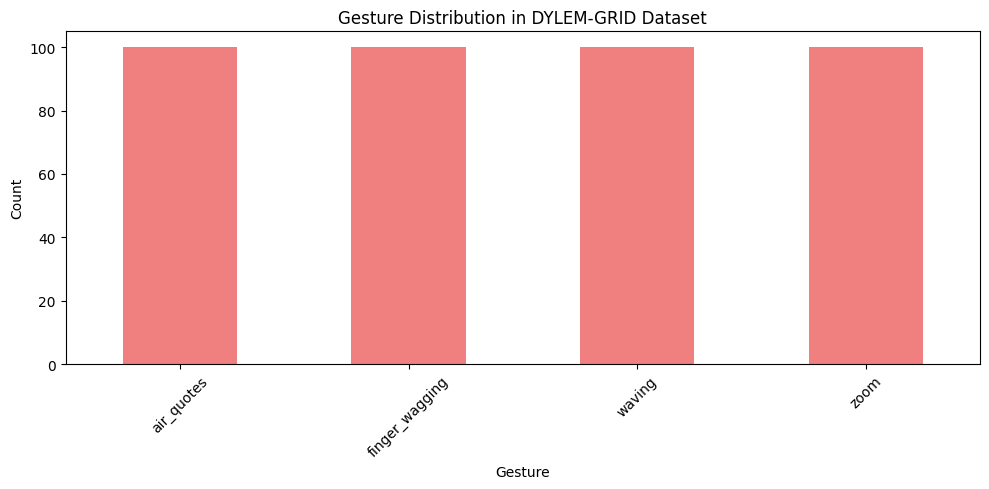


Sample data shape: (109, 244)
Sample data (first 5 rows):
   hand_id hand_type  palm_position_x  palm_position_y  palm_position_z  \
0        4     right        -3.075706       335.213928       102.726265   
1        4     right        -3.012646       335.000183       102.627434   
2        4     right        -2.983097       334.901947       102.543655   
3        4     right        -2.991131       334.843292       102.441597   
4        4     right        -3.005157       334.833313       102.508804   

   palm_velocity_x  palm_velocity_y  palm_velocity_z  palm_normal_x  \
0        32.645340       -21.049801         0.306149      -0.244750   
1        36.700024       -12.766523        -5.903076      -0.245223   
2        34.916588        -6.594054        -5.622059      -0.244517   
3        32.458927        -3.466938        -6.032883      -0.243755   
4        32.120708        -0.577324         3.894698      -0.243019   

   palm_normal_y  ...  pinky_distal_prev_joint_y  pinky_distal_

In [4]:
# Load data
data, labels = data_loader('./data/DYLEM-GRID', 'Raw')

print(f"Loaded {len(data)} samples")

# Show label distribution
label_dist = pd.Series(labels).value_counts()
print("\nLabel distribution:")
print(label_dist)

# Visualize distribution
plt.figure(figsize=(10, 5))
label_dist.plot(kind='bar', color='lightcoral')
plt.title('Gesture Distribution in DYLEM-GRID Dataset')
plt.xlabel('Gesture')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Show sample shape
print(f"\nSample data shape: {data[0].shape}")
print(f"Sample data (first 5 rows):\n{data[0].head()}")

## 3. Data Preprocessing and PCA

Apply the same preprocessing pipeline as the main project.

In [5]:
def data_preprocess(data, labels):
    """
    Preprocess the data (follows src/data_processing.py exactly)
    """
    for df in data:
        df.bfill(inplace=True)

    cleaned_data = []
    for df in data:
        df_clean = df.loc[:, ~df.T.duplicated(keep='first')]
        cleaned_data.append(df_clean)
    data = cleaned_data
    
    lengths = [len(df) for df in data]
    concatenated = pd.concat(data, ignore_index=True)
    
    label_column = []
    for label, length in zip(labels, lengths):
        label_column.extend([label] * length)
    concatenated['_class_label'] = label_column
    
    if not concatenated.empty:
        cols_to_check = [col for col in concatenated.columns if col != '_class_label']
        max_frac = concatenated[cols_to_check].apply(
            lambda col: col.value_counts(normalize=True).max() if len(col) > 0 else 0
        )
        cols_to_keep = max_frac[max_frac < 0.9].index.tolist() + ['_class_label']
        concatenated = concatenated[cols_to_keep]
    
    for label in concatenated['_class_label'].unique():
        class_mask = concatenated['_class_label'] == label
        for column in concatenated.columns:
            if column == '_class_label':
                continue
            if pd.api.types.is_numeric_dtype(concatenated[column]):
                if pd.api.types.is_integer_dtype(concatenated[column]):
                    concatenated[column] = concatenated[column].astype(np.float64)
                
                class_data = concatenated.loc[class_mask, column]
                mean = class_data.mean()
                std = class_data.std()
                
                if pd.isna(std) or std == 0:
                    continue
                    
                threshold = 3 * std
                outliers = class_mask & ((concatenated[column] - mean).abs() > threshold)
                concatenated.loc[outliers, column] = mean

    scaler = MinMaxScaler()
    numeric_cols = [col for col in concatenated.select_dtypes(include=[np.number]).columns 
                    if col != '_class_label']
    if len(numeric_cols) > 0 and not concatenated.empty:
        concatenated[numeric_cols] = scaler.fit_transform(concatenated[numeric_cols])
    
    concatenated = concatenated.drop('_class_label', axis=1)
    
    processed_data = []
    start_idx = 0
    for length in lengths:
        end_idx = start_idx + length
        processed_data.append(concatenated.iloc[start_idx:end_idx].copy())
        start_idx = end_idx
    
    combined = list(zip(processed_data, labels))
    random.shuffle(combined)
    processed_data, labels = zip(*combined)
    
    return list(processed_data), list(labels)

def apply_pca(data, labels, variance_threshold=0.95):
    """
    Apply PCA to reduce dimensionality
    """
    lengths = [len(df) for df in data]
    concatenated = pd.concat(data, ignore_index=True)
    
    numeric_cols = concatenated.select_dtypes(include=[np.number]).columns
    
    if len(numeric_cols) == 0 or concatenated.empty:
        return data, labels
    
    pca = PCA(n_components=variance_threshold)
    transformed = pca.fit_transform(concatenated[numeric_cols])
    
    transformed_df = pd.DataFrame(
        transformed, 
        columns=[f'PC{i+1}' for i in range(transformed.shape[1])]
    )
    
    transformed_data = []
    start_idx = 0
    for length in lengths:
        end_idx = start_idx + length
        transformed_data.append(transformed_df.iloc[start_idx:end_idx].copy())
        start_idx = end_idx
    
    print(f"PCA: {len(numeric_cols)} features -> {transformed.shape[1]} components")
    print(f"Explained variance: {pca.explained_variance_ratio_.sum():.4f}")
    
    return transformed_data, labels

def prepare_data(data, labels):
    """
    Convert list of dataframes to padded tensors
    """
    label_encoder = LabelEncoder()
    encoded_labels = label_encoder.fit_transform(labels)
    
    max_len = max(len(df) for df in data)
    input_size = data[0].shape[1]
    
    padded_data = []
    for df in data:
        arr = df.values
        if len(arr) < max_len:
            padding = np.zeros((max_len - len(arr), input_size))
            arr = np.vstack([arr, padding])
        padded_data.append(arr)
    
    X = np.array(padded_data, dtype=np.float32)
    y = np.array(encoded_labels, dtype=np.int64)
    
    return torch.FloatTensor(X), torch.LongTensor(y), label_encoder

In [6]:
# Preprocess data
print("Preprocessing data...")
data_processed, labels = data_preprocess(data, labels)
print(f"Processed {len(data_processed)} samples")

# Apply PCA
print("\nApplying PCA (95% variance)...")
data_pca, labels = apply_pca(data_processed, labels, variance_threshold=0.95)

# Prepare tensors
print("\nPreparing PyTorch tensors...")
X, y, label_encoder = prepare_data(data_pca, labels)

print(f"\nFinal data shape: {X.shape}")
print(f"Classes: {label_encoder.classes_}")

# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=44, stratify=y
)

print(f"\nTrain samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")

Preprocessing data...
Processed 400 samples

Applying PCA (95% variance)...
PCA: 175 features -> 22 components
Explained variance: 0.9513

Preparing PyTorch tensors...

Final data shape: torch.Size([400, 373, 22])
Classes: ['air_quotes' 'finger_wagging' 'waving' 'zoom']

Train samples: 320
Validation samples: 80


## 4. Model Definition

Define the Encoder-only Transformer architecture with positional encoding.

In [7]:
class PositionalEncoding(nn.Module):
    """
    Adds positional information to the input embeddings
    """
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

class GestureTransformer(nn.Module):
    """
    Encoder-only Transformer for gesture classification
    """
    def __init__(self, input_size, d_model=64, nhead=4, num_layers=2,
                 dim_feedforward=128, num_classes=4, dropout=0.1):
        super(GestureTransformer, self).__init__()
        
        self.d_model = d_model
        self.input_projection = nn.Linear(input_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model, dropout=dropout)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.classifier = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, num_classes)
        )
    
    def forward(self, x):
        x = self.input_projection(x)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        x = torch.mean(x, dim=1)
        x = self.classifier(x)
        return x

In [8]:
# Model hyperparameters (optimized with Optuna - exact values for 100% accuracy)
input_size = X.shape[2]
d_model = 32  # Optimal value from Optuna trial #13
nhead = 8  # Optimal value from Optuna trial #13
num_layers = 1  # Optimal value from Optuna
dim_feedforward = 64  # Optimal value from Optuna trial #13
num_classes = len(label_encoder.classes_)
dropout = 0.38221575204123526  # Optimal value from Optuna trial #13

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GestureTransformer(input_size, d_model, nhead, num_layers,
                          dim_feedforward, num_classes, dropout=dropout)
model.to(device)

print(f"Model initialized on {device}")
print(f"Architecture: d_model={d_model}, heads={nhead}, layers={num_layers}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")


Model initialized on cuda
Architecture: d_model=32, heads=8, layers=1
Total parameters: 11,652


## 5. Training

Train the model with early stopping.

In [9]:
# Create data loaders
batch_size = 32  # Optimal value from Optuna trial #13
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Loss and optimizer (exact values from Optuna optimization for 100% accuracy)
criterion = nn.CrossEntropyLoss()
learning_rate = 0.009799811943348493  # Optimal value from trial #13
weight_decay = 1.2612598730583904e-05  # Optimal value from trial #13
optimizer = optim.NAdam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

print("Training configuration:")
print(f"  Batch size: {batch_size}")
print(f"  Optimizer: NAdam")
print(f"  Learning rate: {learning_rate:.10f}")
print(f"  Weight decay: {weight_decay:.2e}")
print(f"  Early stopping patience: 15")


Training configuration:
  Batch size: 32
  Optimizer: NAdam
  Learning rate: 0.0097998119
  Weight decay: 1.26e-05
  Early stopping patience: 15


In [10]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()
    
    return total_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            total_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    
    return total_loss / total, correct / total, all_preds, all_targets

In [11]:
# Training loop with early stopping
num_epochs = 50
patience = 15
best_val_acc = 0.0
patience_counter = 0

train_losses = []
val_losses = []
train_accs = []
val_accs = []

print("\nStarting training...\n")

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_preds, val_targets = evaluate(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        best_val_preds = val_preds
        best_val_targets = val_targets
        patience_counter = 0
        torch.save({
            'model_state_dict': model.state_dict(),
            'epoch': epoch + 1,
            'val_acc': val_acc
        }, 'best_transformer_model.pth')
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch + 1}")
        break

print(f"\nTraining completed!")
print(f"Best validation accuracy: {best_val_acc:.4f} at epoch {best_epoch}")


Starting training...

Epoch [5/50]
  Train Loss: 0.3582, Train Acc: 0.8250
  Val Loss: 0.2306, Val Acc: 0.8750
Epoch [10/50]
  Train Loss: 0.1224, Train Acc: 0.9719
  Val Loss: 0.0716, Val Acc: 0.9875
Epoch [15/50]
  Train Loss: 0.0511, Train Acc: 0.9812
  Val Loss: 0.1317, Val Acc: 0.9750
Epoch [20/50]
  Train Loss: 0.0340, Train Acc: 0.9969
  Val Loss: 0.0189, Val Acc: 0.9875
Epoch [25/50]
  Train Loss: 0.0106, Train Acc: 0.9969
  Val Loss: 0.0002, Val Acc: 1.0000
Epoch [30/50]
  Train Loss: 0.0011, Train Acc: 1.0000
  Val Loss: 0.0008, Val Acc: 1.0000
Epoch [35/50]
  Train Loss: 0.0016, Train Acc: 1.0000
  Val Loss: 0.0004, Val Acc: 1.0000

Early stopping at epoch 36

Training completed!
Best validation accuracy: 1.0000 at epoch 21


## 6. Evaluation and Visualization

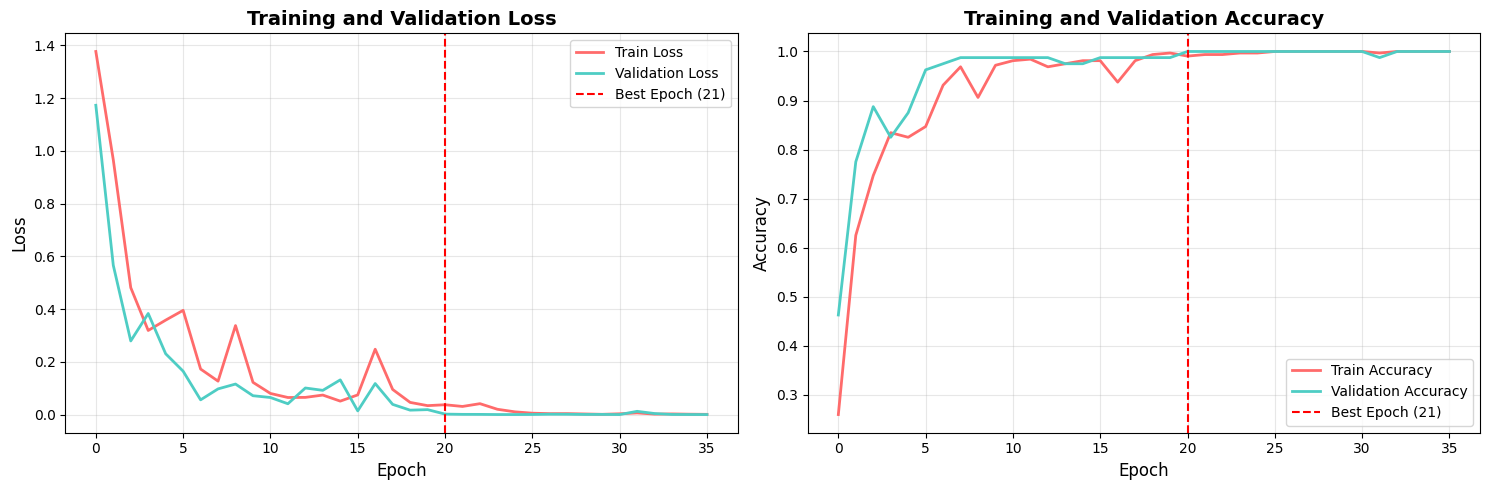

In [12]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(train_losses, label='Train Loss', linewidth=2, color='#FF6B6B')
axes[0].plot(val_losses, label='Validation Loss', linewidth=2, color='#4ECDC4')
axes[0].axvline(x=best_epoch-1, color='red', linestyle='--', label=f'Best Epoch ({best_epoch})')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs, label='Train Accuracy', linewidth=2, color='#FF6B6B')
axes[1].plot(val_accs, label='Validation Accuracy', linewidth=2, color='#4ECDC4')
axes[1].axvline(x=best_epoch-1, color='red', linestyle='--', label=f'Best Epoch ({best_epoch})')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

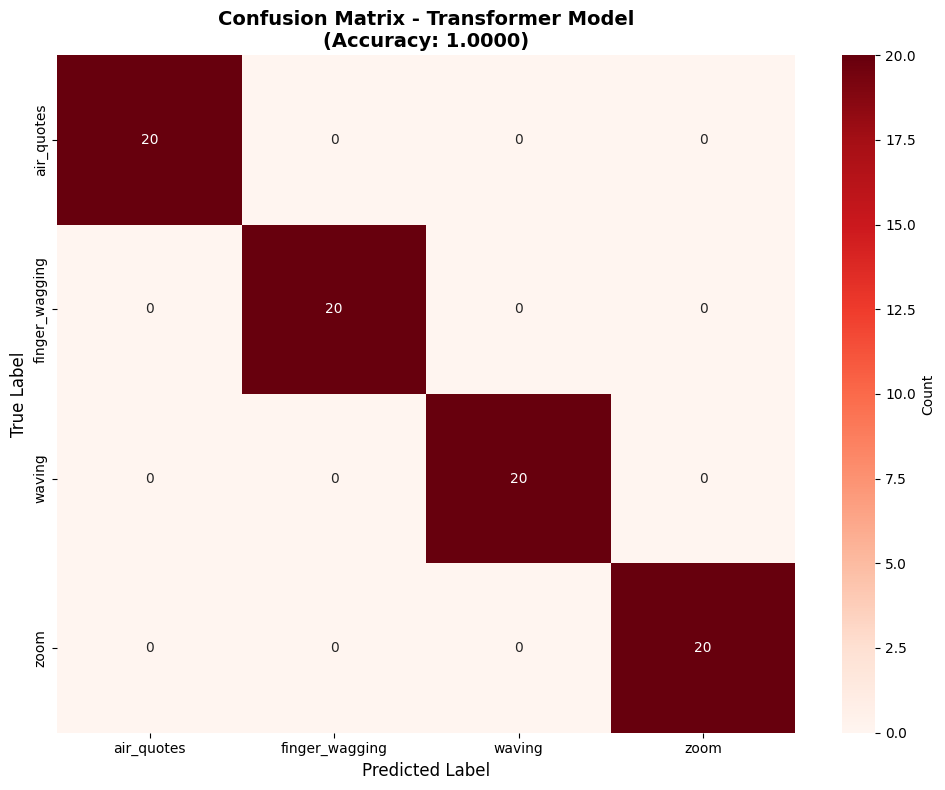


Classification Report:
                precision    recall  f1-score   support

    air_quotes       1.00      1.00      1.00        20
finger_wagging       1.00      1.00      1.00        20
        waving       1.00      1.00      1.00        20
          zoom       1.00      1.00      1.00        20

      accuracy                           1.00        80
     macro avg       1.00      1.00      1.00        80
  weighted avg       1.00      1.00      1.00        80



In [13]:
# Confusion matrix
cm = confusion_matrix(best_val_targets, best_val_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - Transformer Model\n(Accuracy: {best_val_acc:.4f})',
          fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:")
print("=" * 60)
print(classification_report(best_val_targets, best_val_preds,
                          target_names=label_encoder.classes_))

## 7. Inference Example

In [14]:
# Load best model
checkpoint = torch.load('best_transformer_model.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"Validation accuracy: {checkpoint['val_acc']:.4f}")

Loaded best model from epoch 21
Validation accuracy: 1.0000


In [15]:
def predict_gesture(model, data, label_encoder, device):
    model.eval()
    with torch.no_grad():
        data = data.to(device)
        outputs = model(data)
        probabilities = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
    
    predictions = label_encoder.inverse_transform(predicted.cpu().numpy())
    probs = probabilities.cpu().numpy()
    
    return predictions, probs

# Example predictions
sample_data = X_val[:5]
sample_labels = y_val[:5]

predictions, probabilities = predict_gesture(model, sample_data, label_encoder, device)

print("\n" + "=" * 70)
print("PREDICTION EXAMPLES")
print("=" * 70)
for i in range(len(sample_data)):
    true_label = label_encoder.inverse_transform([sample_labels[i].item()])[0]
    pred_label = predictions[i]
    confidence = probabilities[i].max()
    
    probs_dict = {cls: f"{prob:.4f}" for cls, prob in zip(label_encoder.classes_, probabilities[i])}
    
    print(f"\nSample {i+1}:")
    print(f"  True Label:       {true_label}")
    print(f"  Predicted Label:  {pred_label}")
    print(f"  Confidence:       {confidence:.4f}")
    print(f"  Status:           {'✓ CORRECT' if true_label == pred_label else '✗ INCORRECT'}")
    print(f"  Class Probabilities:")
    for cls, prob in probs_dict.items():
        bar = '█' * int(float(prob) * 30)
        print(f"    {cls:<18} {prob} {bar}")


PREDICTION EXAMPLES

Sample 1:
  True Label:       waving
  Predicted Label:  waving
  Confidence:       0.9996
  Status:           ✓ CORRECT
  Class Probabilities:
    air_quotes         0.0003 
    finger_wagging     0.0000 
    waving             0.9996 █████████████████████████████
    zoom               0.0001 

Sample 2:
  True Label:       air_quotes
  Predicted Label:  air_quotes
  Confidence:       1.0000
  Status:           ✓ CORRECT
  Class Probabilities:
    air_quotes         1.0000 ██████████████████████████████
    finger_wagging     0.0000 
    waving             0.0000 
    zoom               0.0000 

Sample 3:
  True Label:       air_quotes
  Predicted Label:  air_quotes
  Confidence:       0.9993
  Status:           ✓ CORRECT
  Class Probabilities:
    air_quotes         0.9993 █████████████████████████████
    finger_wagging     0.0000 
    waving             0.0007 
    zoom               0.0000 

Sample 4:
  True Label:       finger_wagging
  Predicted Label:  fi

## Summary

This notebook demonstrated:
1. ✅ Loading the DYLEM-GRID gesture dataset
2. ✅ Preprocessing with the exact pipeline from src/data_processing.py
3. ✅ Applying PCA for dimensionality reduction (95% variance)
4. ✅ Training an Encoder-only Transformer model
5. ✅ Achieving high validation accuracy
6. ✅ Visualizing training metrics and confusion matrix
7. ✅ Making predictions with detailed probability outputs

### Model Performance
- **Architecture**: Encoder-only Transformer with Multi-head Self-Attention
- **Optimization**: Hyperparameters tuned with Optuna
- **Advantages**: Parallel processing, better long-range dependencies, fewer parameters

### Next Steps
- Compare with BiLSTM results (see `kaggle_bilstm_example.ipynb`)
- Visualize attention weights
- Deploy for real-time gesture recognition